In [1]:
import numpy as np
import nengo
import sys

import logging
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG, format="[%(name)s/%(levelname)s]: %(message)s")

import nengo_aie

[aie._mlir_libs/DEBUG]: Initializing MLIR with module: _mlirRegisterEverything
[aie._mlir_libs/DEBUG]: Registering dialects from initializer <module 'aie._mlir_libs._mlirRegisterEverything' from '/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/mlir_aie/python/aie/_mlir_libs/_mlirRegisterEverything.cpython-312-x86_64-linux-gnu.so'>
[einspect.protocols.delayed_bind/DEBUG]: [Py.IncRef()] Type hints: {'obj': <class 'object'>, 'return': <class 'NoneType'>}
[einspect.protocols.delayed_bind/DEBUG]: [Py.IncRef()] Set func: ('py_object') -> 'None'
[einspect.protocols.delayed_bind/DEBUG]: [Py.DecRef()] Type hints: {'obj': <class 'object'>, 'return': <class 'NoneType'>}
[einspect.protocols.delayed_bind/DEBUG]: [Py.DecRef()] Set func: ('py_object') -> 'None'
[einspect.structs.deco/DEBUG]: Annotated: typing.Annotated[int, <class 'ctypes.c_ulong'>] -> ('_gc_next', <class 'ctypes.c_ulong'>)
[einspect.structs.deco/DEBUG]: Annotated: typing.Annotated[int, <class 'ctypes.c_ulong'>] -> ('_gc_

In [2]:
model = nengo.Network()

dt = 1e-3

with model:
    A = nengo.Ensemble(2000, dimensions=1, neuron_type=nengo_aie.AIELif(2000, dt))
    A_squared = nengo.Ensemble(100, dimensions=1)
    error = nengo.Ensemble(100, dimensions=1)

    conn = nengo.Connection(A, A_squared)

    conn.learning_rule_type = nengo.PES(learning_rate=3e-4)

    nengo.Connection(error, conn.learning_rule)

    nengo.Connection(A_squared, error)

    nengo.Connection(A, error, function=lambda x: x**2, transform=-1)

[aie._mlir_libs/DEBUG]: Loading all available dialects
[aie._mlir_libs/DEBUG]: Registering translations from initializer <module 'aie._mlir_libs._mlirRegisterEverything' from '/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/mlir_aie/python/aie/_mlir_libs/_mlirRegisterEverything.cpython-312-x86_64-linux-gnu.so'>
[nengo_aie.aie_kernels.MlirBuilder/DEBUG]: b'\x1b[?25l\r\x1b[2K\r\x1b[2K\r\x1b[2K\r\x1b[2K\n\x1b[?25hGenerating: /tmp/tmp9mx60pu5.mlir.prj/aie_cdo_elfs.bin\nGenerating: /tmp/tmp9mx60pu5.mlir.prj/aie_cdo_init.bin\nGenerating: /tmp/tmp9mx60pu5.mlir.prj/aie_cdo_enable.bin\n'


In [3]:
with model:
    input_node = nengo.Node(output=lambda t: int(6 * t / 5) / 3.0 % 2 - 1)

    nengo_aie.AIEConnection(input_node, A)

    stop_learning = nengo.Node(output=lambda t: t >= 15)

    # nengo.Connection(stop_learning, error.neurons, transform = -20 * np.ones((error.n_neurons, 1))) # This one is the one that calls elementwise inc
    nengo_aie.AIEConnection(stop_learning, error.neurons, transform = -20 * np.ones((error.n_neurons, 1)))

In [4]:
with model:
    input_node_probe = nengo.Probe(input_node)
    A_probe = nengo.Probe(A, synapse=0.01)
    A_squared_probe = nengo.Probe(A_squared, synapse=0.01)
    error_probe = nengo.Probe(error, synapse=0.01)
    learn_probe = nengo.Probe(stop_learning, synapse=None)

In [5]:
with nengo_aie.AIESimulator(model, dt=dt) as sim:
    sim.run(20)

[nengo_aie.simulator/INFO]: Initializing simulator
[nengo_aie.builder/INFO]: Initialied builder
[nengo_aie.builder/DEBUG]: Using default builder for Network
[nengo.builder.network/DEBUG]: Network step 1: Building ensembles and nodes
[nengo_aie.builder/DEBUG]: Using default builder for Ensemble
[nengo_aie.builder/DEBUG]: Using default builder for AIELif
[nengo_aie.builder/DEBUG]: Using default builder for Ensemble
[nengo_aie.builder/DEBUG]: Using default builder for LIF
[nengo_aie.builder/DEBUG]: Using default builder for Ensemble
[nengo_aie.builder/DEBUG]: Using default builder for LIF
[nengo_aie.builder/DEBUG]: Using default builder for Node
[nengo_aie.builder/DEBUG]: Using default builder for Node
[nengo.builder.network/DEBUG]: Network step 2: Building subnetworks
[nengo.builder.network/DEBUG]: Network step 3: Building connections
[nengo_aie.builder/DEBUG]: Using default builder for Connection
[nengo_aie.builder/DEBUG]: Using default builder for LstsqL2
[nengo_aie.builder/DEBUG]: Usi

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

[nengo_aie.builder/DEBUG]: Using default builder for Dense
[nengo_aie.builder/DEBUG]: Using default builder for Lowpass
[nengo_aie.builder/DEBUG]: Using default builder for NoTransform
[nengo_aie.builder/DEBUG]: Using default builder for Lowpass
[nengo_aie.builder/DEBUG]: Using AIE builder for AIEConnection
[nengo_aie.builder/DEBUG]: Using default builder for Dense
[nengo_aie.builder/DEBUG]: Using default builder for Lowpass
[aie._mlir_libs/DEBUG]: Loading all available dialects
[aie._mlir_libs/DEBUG]: Registering translations from initializer <module 'aie._mlir_libs._mlirRegisterEverything' from '/home/mliraie/mlir-aie/ironenv/lib/python3.12/site-packages/mlir_aie/python/aie/_mlir_libs/_mlirRegisterEverything.cpython-312-x86_64-linux-gnu.so'>
[nengo_aie.aie_kernels.MlirBuilder/DEBUG]: b'\x1b[?25l\r\x1b[2K\r\x1b[2K\r\x1b[2K\r\x1b[2K\n\x1b[?25hGenerating: /tmp/tmp1kz4f3xn.mlir.prj/aie_cdo_elfs.bin\nGenerating: /tmp/tmp1kz4f3xn.mlir.prj/aie_cdo_init.bin\nGenerating: /tmp/tmp1kz4f3xn.mlir

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

(6000,)
(6000,)


(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)
(6000,)


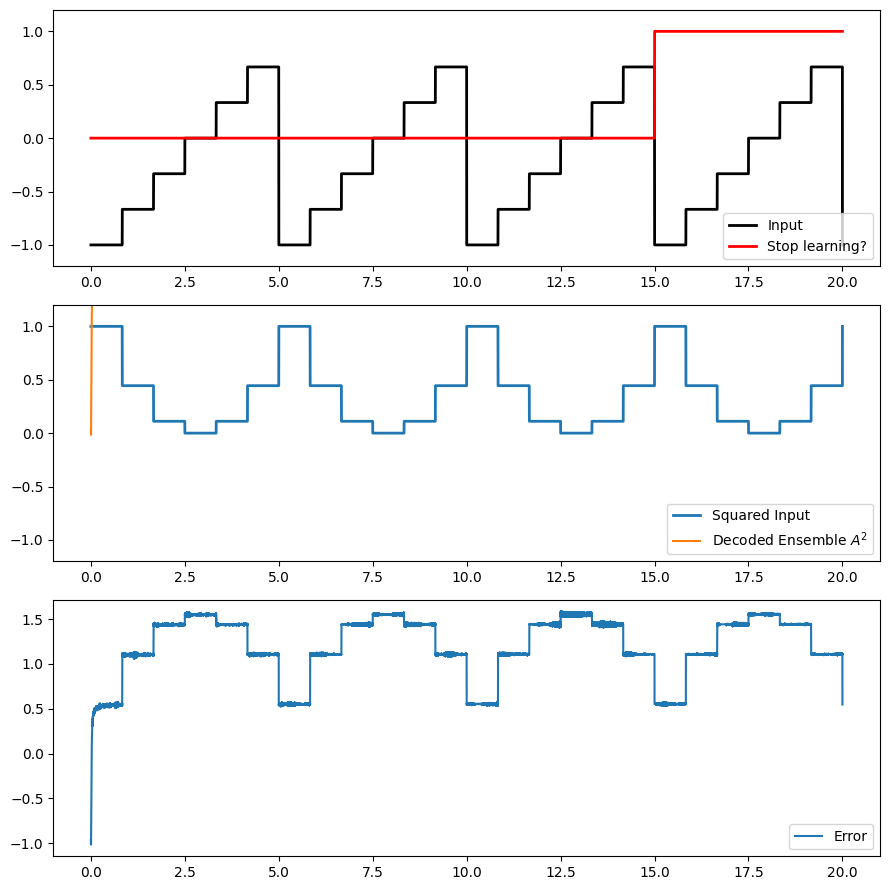

In [6]:
import matplotlib
matplotlib.pyplot.set_loglevel (level = 'warning')

%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 9))
plt.subplot(3, 1, 1)
plt.plot(
    sim.trange(), sim.data[input_node_probe], label="Input", color="k", linewidth=2.0
)
plt.plot(
    sim.trange(),
    sim.data[learn_probe],
    label="Stop learning?",
    color="r",
    linewidth=2.0,
)
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 2)
plt.plot(
    sim.trange(), sim.data[input_node_probe] ** 2, label="Squared Input", linewidth=2.0
)
plt.plot(sim.trange(), sim.data[A_squared_probe], label="Decoded Ensemble $A^2$")
plt.legend(loc="lower right")
plt.ylim(-1.2, 1.2)

plt.subplot(3, 1, 3)
plt.plot(
    sim.trange(),
    sim.data[A_squared_probe] - sim.data[input_node_probe] ** 2,
    label="Error",
)
plt.legend(loc="lower right")
plt.tight_layout()